# 📡 Customer Churn Prediction — EDA
IBM Telco Dataset · 7,043 records · 21 features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
print(df.shape)
df.head()

(7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


Churn rate: 26.5%


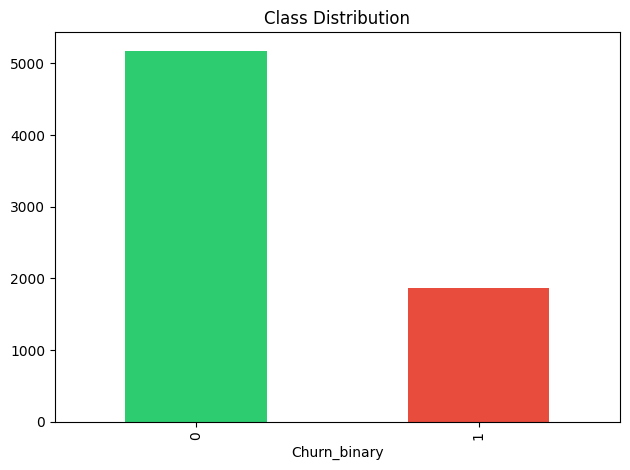

In [2]:
# Churn rate
print(f'Churn rate: {df["Churn_binary"].mean():.1%}')
df['Churn_binary'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'])
plt.title('Class Distribution'); plt.tight_layout(); plt.show()

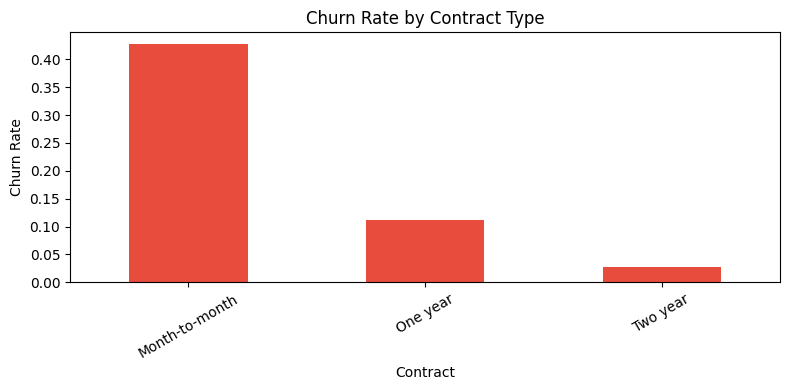

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_binary, dtype: float64


In [3]:
# Churn by contract type (key predictor)
ct = df.groupby('Contract')['Churn_binary'].mean().sort_values(ascending=False)
ct.plot(kind='bar', color='#e74c3c', figsize=(8,4))
plt.title('Churn Rate by Contract Type'); plt.ylabel('Churn Rate')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()
print(ct)

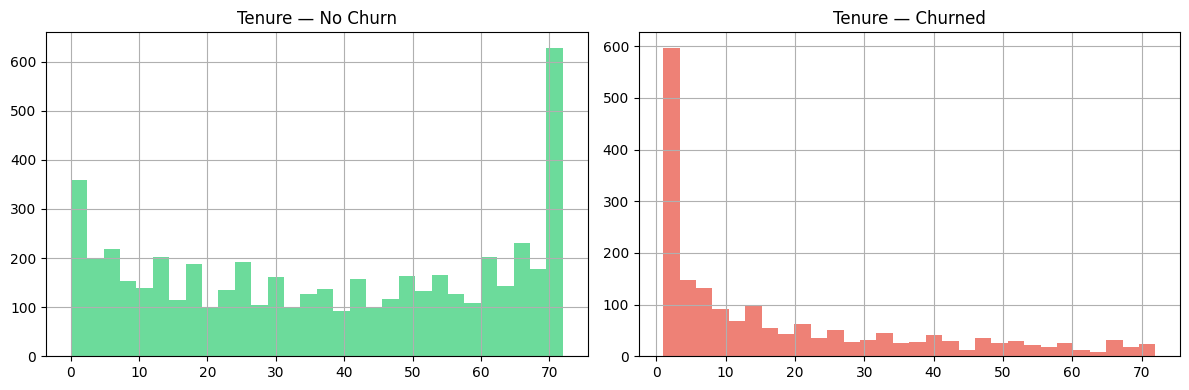

In [4]:
# Tenure distribution by churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df['Churn']=='No']['tenure'].hist(ax=axes[0], bins=30, color='#2ecc71', alpha=0.7)
axes[0].set_title('Tenure — No Churn')
df[df['Churn']=='Yes']['tenure'].hist(ax=axes[1], bins=30, color='#e74c3c', alpha=0.7)
axes[1].set_title('Tenure — Churned')
plt.tight_layout(); plt.show()

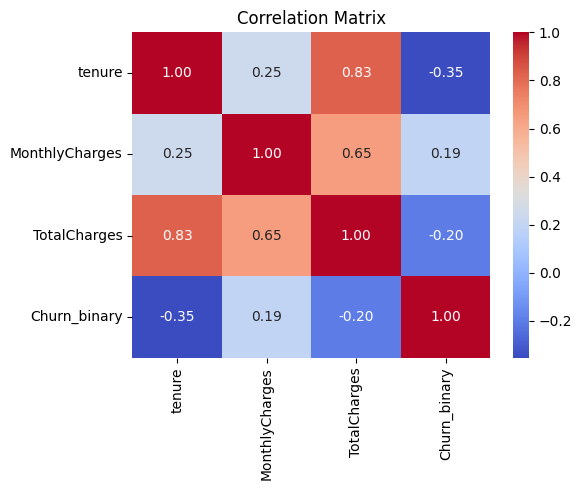

In [5]:
# Correlation heatmap for numeric cols
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix'); plt.tight_layout(); plt.show()

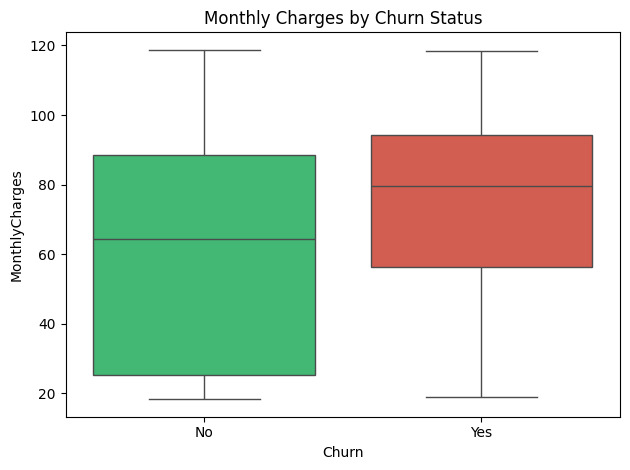

In [6]:
# Monthly charges vs churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette={'No':'#2ecc71','Yes':'#e74c3c'})
plt.title('Monthly Charges by Churn Status'); plt.tight_layout(); plt.show()